# Data analysis in Astronomy 

### Homework 3 due 11/18 11:59 pm

### Name: Cheng-An, Hsieh

In [2]:
import numpy as np
import astropy.io.fits as pf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as ss

### 1. A few weeks ago, you have learned how to do simple cross-correlation measurements. 
### Now extend your code to calculate mean($\delta y$) (mean(y_x)-mean(y_0)) when x = 1, 2, 3, 4. Estimate the uncertainty with bootstrap. 
### To do: 
### a. Estimate the uncertainty with the error of the mean and propagate the uncertainty. Compare the estimated uncertainty based on the error propagation and bootstrapping. (5 points) 
### b. Produce a plot with xaxis showing x=[1,2,3,4], and with yaxis showing the corresponding delta y values. (Please include the uncertainty) (5 points)

you can find the data at https://www.dropbox.com/s/ak159coklf1eplf/simple_correlation_10000_x_y_01234.npy?dl=0
### c. Do the linear regression with a model, delta y= a x, and get the best fit a parameter value. Plot your best-fit model in the figure. (15 points) 

### -----------------------------------------------------------------------------------------------------------------

In [2]:
### a. Estimate the uncertainty with the error of the mean and propagate the uncertainty. 
# Compare the estimated uncertainty based on the error propagation and bootstrapping. (5 points) 

def bootstrap(x, y, n  = 1000):
    
    errors = []
    n_bootstrap = n
    if len(x) <= len(y):
        n_point = len(x)
    else:
        n_point = len(y)
    for _ in range(n_bootstrap):
        indices = np.random.randint(0, n_point, n_point)
        sample_x = x[indices]
        sample_y = y[indices]
        mean_diff = np.mean(sample_y) - np.mean(sample_x)
        errors.append(mean_diff)
    bootstrap_error = np.std(errors)
    return bootstrap_error

# Load the data
data = np.array(np.load('simple_correlation_10000_x_y_01234.npy'))

x = data[0]
y = data[1] 

# Calculate mean(Δy) for x = 1, 2, 3, 4 and estimate uncertainty with bootstrap
mean_dy_values = []
bootstrap_errors = []

for i in range(1, 5):
    y_x = y[x == i]
    y_0 = y[x == 0]

    if len(y_x) > 0 and len(y_0) > 0:
        mean_y_x = np.mean(y_x)
        mean_y_0 = np.mean(y_0)
        
        mean_dy = mean_y_x - mean_y_0
        mean_dy_values.append(mean_dy)
        
        # Bootstrap uncertainty for Δy
        bootstrap_error_dy = bootstrap(y_x, y_0)
        bootstrap_errors.append(bootstrap_error_dy)

        # Print mean(Δy) and bootstrap uncertainty
        print(f"x = {i}")
        print(f'Δy = ', mean_dy)
        print(f'Bootstrap uncertainty = ', bootstrap_error_dy)



x = 1
Δy =  0.8629218120669719
Bootstrap uncertainty =  0.32281237504746013
x = 2
Δy =  1.9883009686514441
Bootstrap uncertainty =  0.3246662322981282
x = 3
Δy =  2.7669224874977942
Bootstrap uncertainty =  0.31861092108749517
x = 4
Δy =  4.271115825836489
Bootstrap uncertainty =  0.3047744046483611


<class 'list'> <class 'list'>


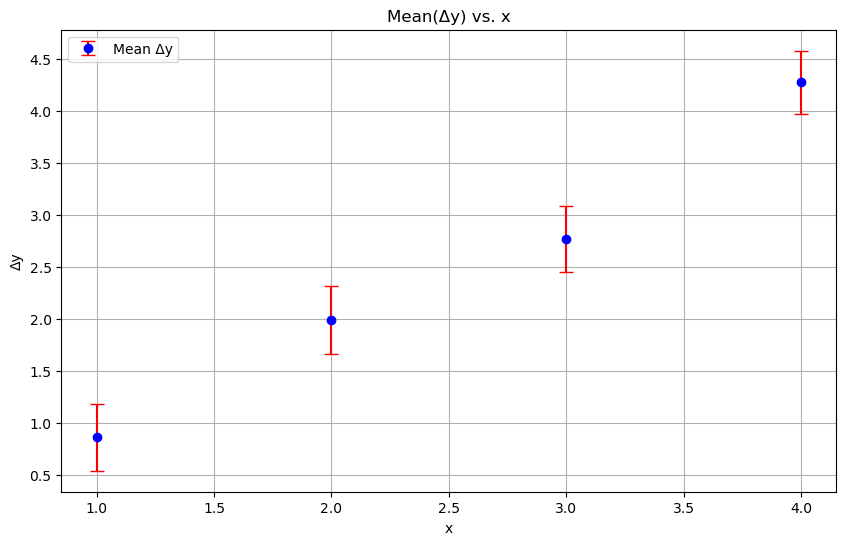

In [3]:


np.array(mean_dy_values)
np.array(bootstrap_errors)
x_values = [1, 2, 3, 4]
np.array(x_values)

print(type(mean_dy_values), type(bootstrap_errors))


plt.figure(figsize=(10, 6))

plt.errorbar(
    x_values,
    mean_dy_values,
    yerr=bootstrap_errors,
    fmt='o',
    color='blue',
    ecolor='red',
    capsize=5,
    label='Mean Δy'
)

plt.xlabel('x')
plt.ylabel('Δy')
plt.title('Mean(Δy) vs. x')
plt.grid(True)
plt.legend()
plt.show()


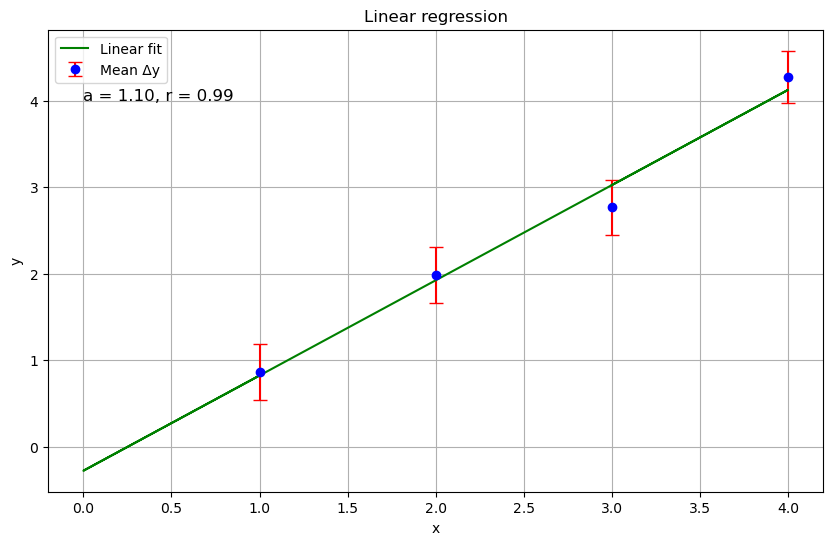

In [11]:
### c. Do the linear regression with a model, delta y= a x, and get the best fit a parameter value.
#  Plot your best-fit model in the figure. (15 points) 

# Linear regression
slope, intercept, r_value, p_value, std_err = ss.linregress(x_values, mean_dy_values)

plt.figure(figsize=(10, 6))

plt.errorbar(
    x_values,
    mean_dy_values,
    yerr=bootstrap_errors,
    fmt='o',
    color='blue',
    ecolor='red',
    capsize=5,
    label='Mean Δy'
)

plt.plot(
    x,
    slope * x + intercept,
    color='green',
    label='Linear fit'
)

plt.text(0, 4, f'a = {slope:.2f}, r = {r_value:.2f}', fontsize=12, color='black')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear regression')
plt.grid(True)
plt.legend()
plt.show()

### 2. Finish fitting the black body spectrum


### To do:

### Finish writing the blackbody model and get the best-fit temperature and uncertainty of the spectrum. (10 points) 

In [20]:
# https://www.dropbox.com/s/c8qomgjpbvlj87o/hubble_original_data.fits?dl=0

In [13]:
black_body = pf.getdata('spec-3744-55209-0386.fits',1)
# https://www.dropbox.com/s/n2xrychdkulsqjp/spec-3744-55209-0386.fits?dl=0

In [14]:
search = np.where(black_body['ivar']>0)

In [15]:
flux = black_body['flux'][search[0]].astype('float64')
wavelength = 10**black_body['loglam'][search[0]].astype('float64')
ivar = black_body['ivar'][search[0]].astype('float64')

Text(0, 0.5, 'Flux')

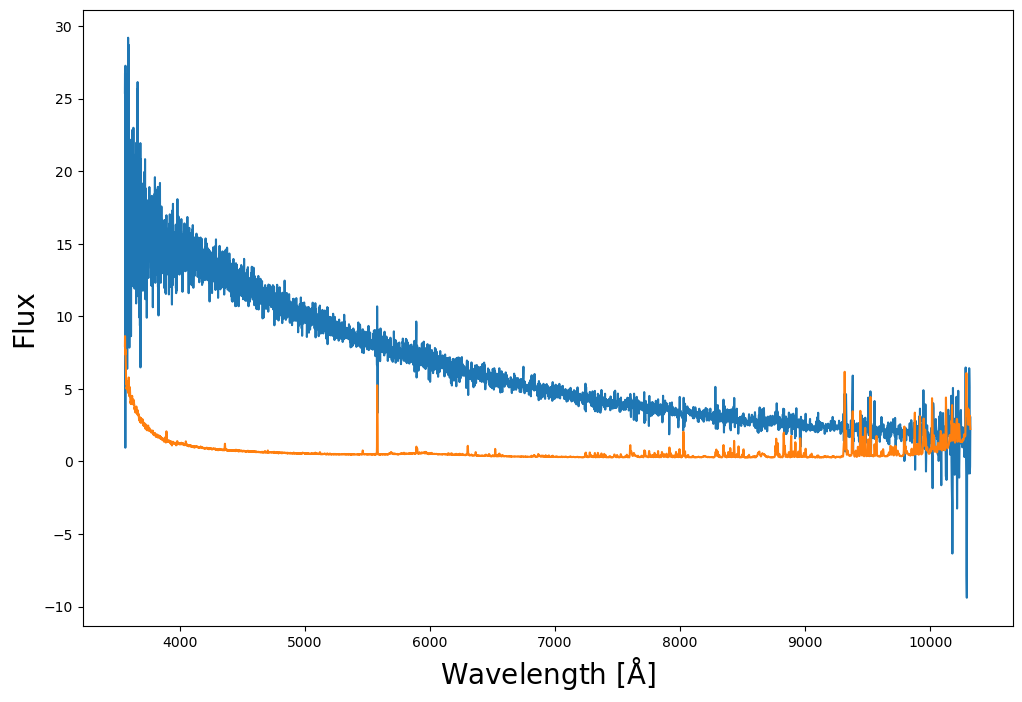

In [16]:
plt.figure(figsize=(12,8))
plt.plot(wavelength,flux)
plt.plot(wavelength,1./np.sqrt(ivar))
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux',fontsize=20)

In [17]:
def blackbody_SED(x, T, A):
    h, c, k = 6.626e-34, 3.0e8, 1.38e-23  # Planck constant, speed of light, Boltzmann constant
    temperature = T
    a = A
    f_lambda =   a * (2.0 * h * c**2) / (x**5 * (np.exp(h * c / (x * k * temperature)) - 1.0))
    # Write the content 
    # parameter [amplitude and temperature]
    # Let's just get the temperature right
    return f_lambda

In [18]:
def residual_function(p,data):
    x,y,y_ivar = data
    return np.sqrt(y_ivar)*(y-blackbody_SED(p,x))

wavelength_SI = wavelength * 1e-10
print(wavelength)


[ 3560.41057274  3561.22964051  3562.0508522  ... 10315.73586855
 10318.10332561 10320.48265745]


9652.279536996053 4.996818402534921e-14


Text(0, 0.5, 'Flux')

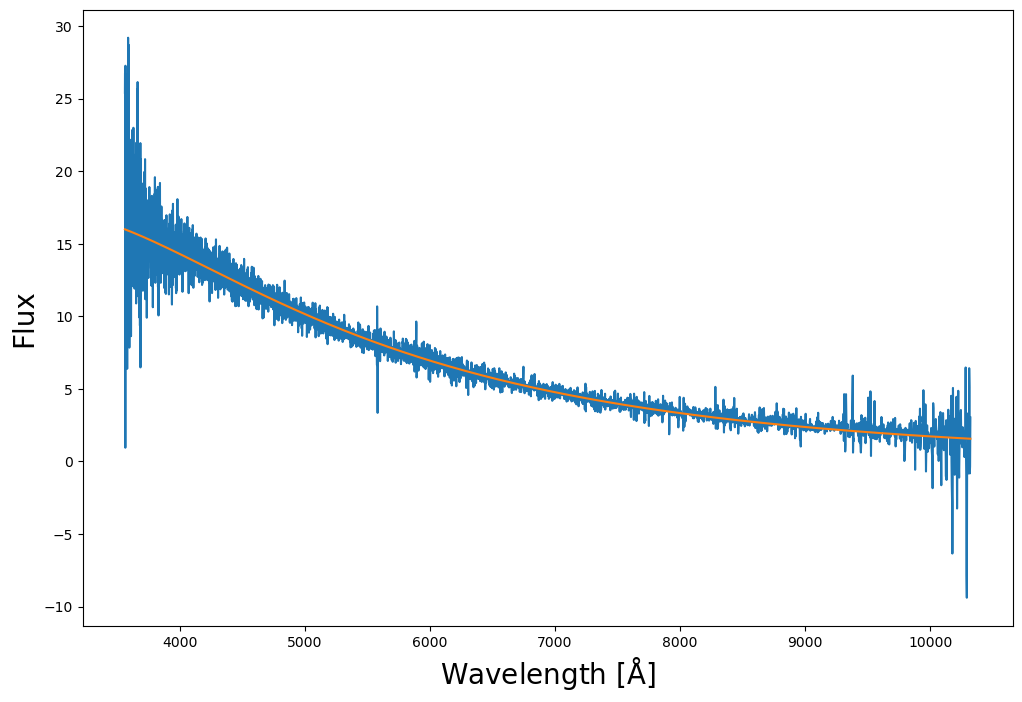

In [19]:
from scipy.optimize import curve_fit

paramsinitial =  [5000, 1]

# Perform the fit
popt, conv= curve_fit(blackbody_SED, wavelength_SI, flux, p0=paramsinitial, maxfev=20000, sigma=1./np.sqrt(ivar), absolute_sigma=True)

print(popt[0], popt[1])

plt.figure(figsize=(12,8))
plt.plot(wavelength,flux)
plt.plot(wavelength,blackbody_SED(wavelength_SI,popt[0],popt[1]))
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux',fontsize=20)

### -----------------------------------------------------------------

### 3. Measuring the rest equavalent width

### The rest equivalent width (the area of flux absorbed by the gas) of an absorption line contains physical information about the abundance of the gas. Astronomers frequently need to measure the rest equivalent width of absorption lines. 

### We now have 6 absorption line spectra. The two absorption lines are MgII 2796 and 2803. Their exact wavelengths are 2796.35 and 2803.53 Angstrom. 

### The goal is to obtain the rest equivalent widths of the two absorption lines for the 6 spectra. 

### To do:

### 1. Write a function consisting of two gaussians with central wavelengths at 2796.35 and 2803.53 Angstrom and obtain the best fit parameters of the gaussians. Based on the best fit parameters, you can get the rest equivalent widths of the absorption lines and the uncertainty of the rest equivalent widths. (You need to input the error array as well when doing the fitting.) (15 points) 

### 2. Plot the best fit models with the absorption line spectra together to demonstrate that what you get is truly the best fit models. (Similar to Figure 11 in https://ui.adsabs.harvard.edu/abs/2017ApJ...850..156L/abstract) (15 points) 

You can find the data at https://www.dropbox.com/s/bp63yptckslvzd5/Simple_absorption_line_spectra.fits?dl=0

The data structure can be found below. 

In [86]:
data = pf.open('Simple_absorption_line_spectra.fits')

In [87]:
spectra = data[0].data
error = data[1].data
wavelength = data[2].data

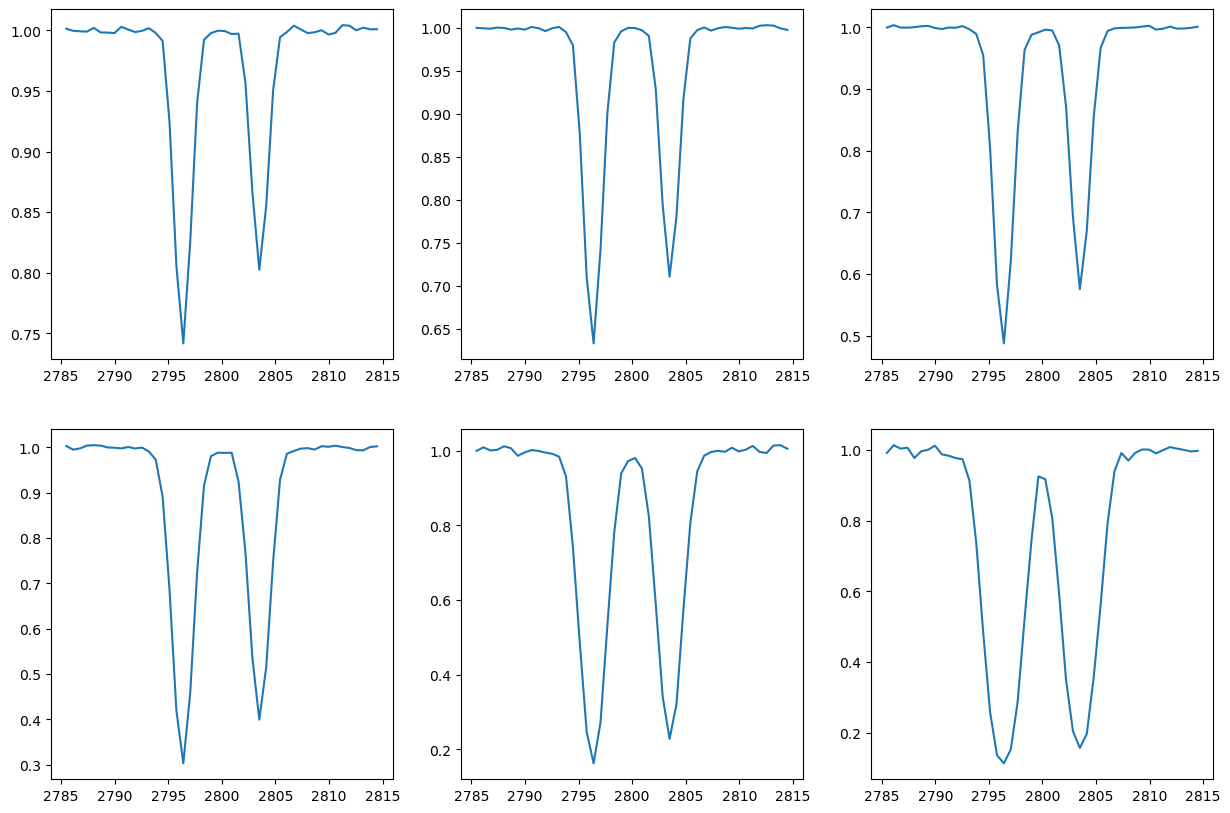

In [88]:
plt.figure(figsize=(15,10))
for i in range(0,len(spectra[:,0])):
    plt.subplot(2,3,i+1)
    plt.plot(wavelength,spectra[i,:])

Processing Spectrum 1/6


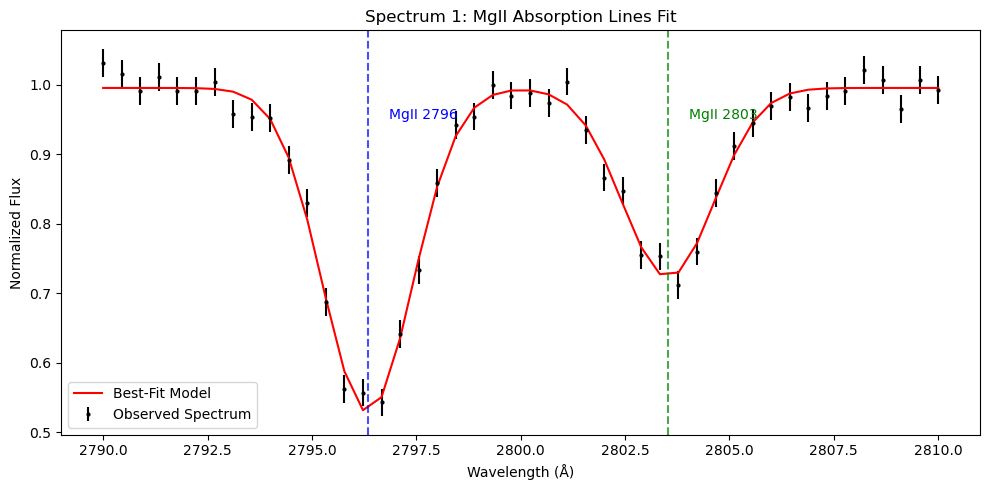

Best-Fit Parameters:
  continuum: 0.9952
  gaussian1_amplitude: -0.4658
  gaussian1_mean: 2796.3362
  gaussian1_stddev: 1.0790
  gaussian2_amplitude: -0.2721
  gaussian2_mean: 2803.5314
  gaussian2_stddev: 1.0970
Rest Equivalent Widths:
  MgII_2796_EW: 1.2598 Å ± 0.0530 Å
  MgII_2803_EW: 0.7483 Å ± 0.0535 Å

--------------------------------------------------

Processing Spectrum 2/6


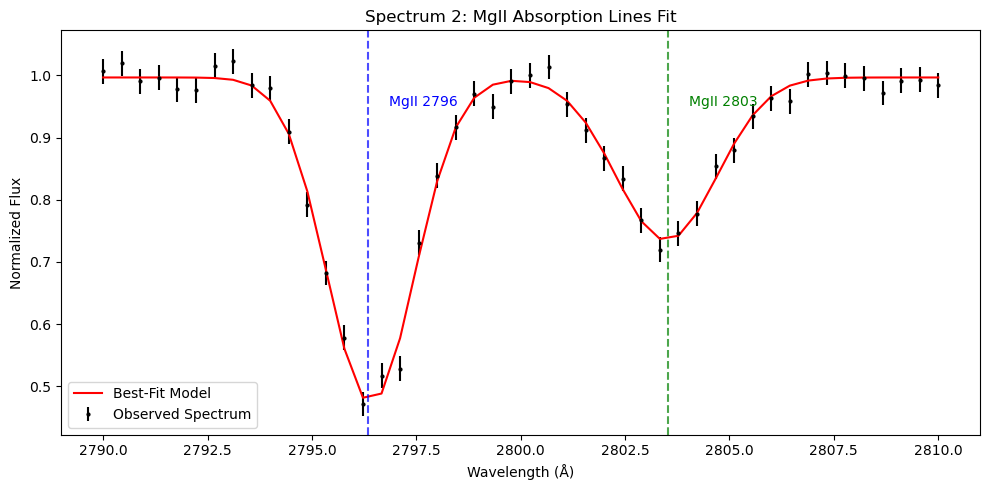

Best-Fit Parameters:
  continuum: 0.9966
  gaussian1_amplitude: -0.5236
  gaussian1_mean: 2796.4116
  gaussian1_stddev: 1.0499
  gaussian2_amplitude: -0.2619
  gaussian2_mean: 2803.4911
  gaussian2_stddev: 1.2073
Rest Equivalent Widths:
  MgII_2796_EW: 1.3781 Å ± 0.0524 Å
  MgII_2803_EW: 0.7926 Å ± 0.0566 Å

--------------------------------------------------

Processing Spectrum 3/6


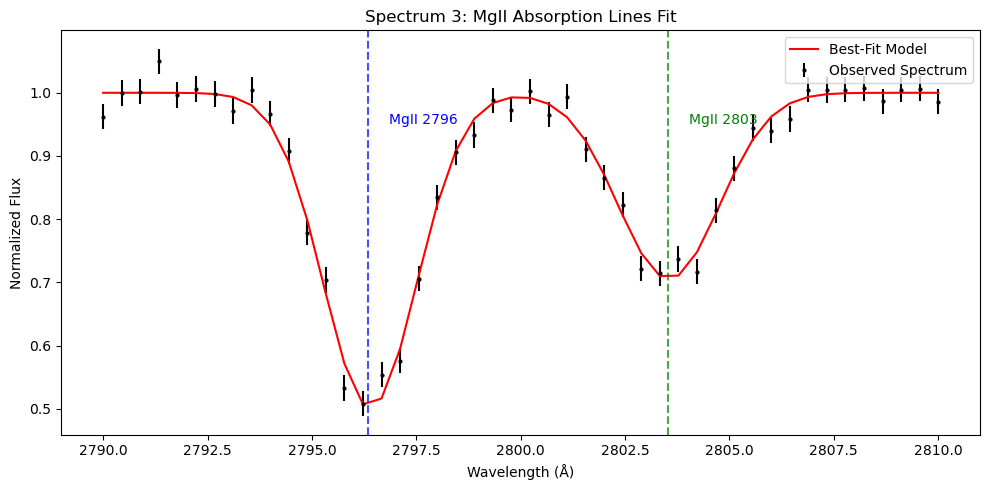

Best-Fit Parameters:
  continuum: 0.9996
  gaussian1_amplitude: -0.4980
  gaussian1_mean: 2796.3921
  gaussian1_stddev: 1.1165
  gaussian2_amplitude: -0.2942
  gaussian2_mean: 2803.5474
  gaussian2_stddev: 1.2090
Rest Equivalent Widths:
  MgII_2796_EW: 1.3937 Å ± 0.0543 Å
  MgII_2803_EW: 0.8916 Å ± 0.0568 Å

--------------------------------------------------

Processing Spectrum 4/6


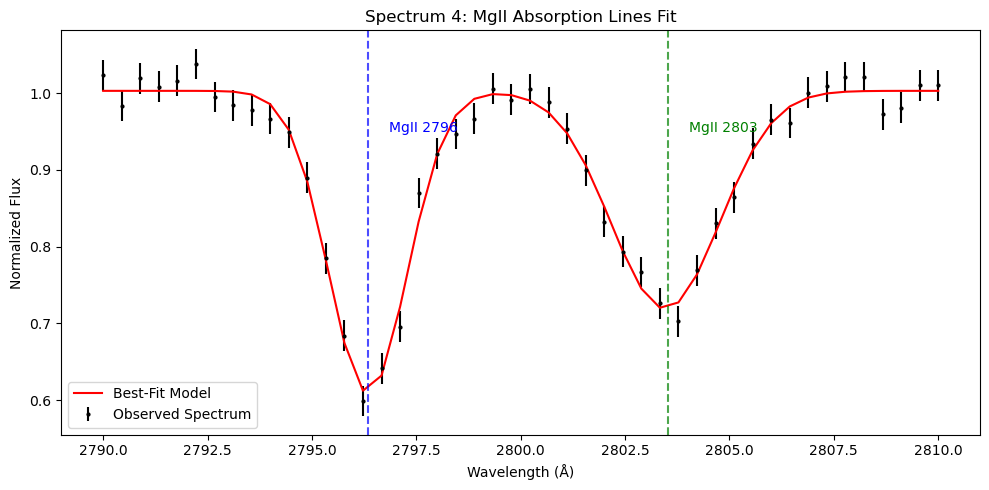

Best-Fit Parameters:
  continuum: 1.0030
  gaussian1_amplitude: -0.3939
  gaussian1_mean: 2796.3425
  gaussian1_stddev: 0.9370
  gaussian2_amplitude: -0.2840
  gaussian2_mean: 2803.4615
  gaussian2_stddev: 1.2989
Rest Equivalent Widths:
  MgII_2796_EW: 0.9253 Å ± 0.0493 Å
  MgII_2803_EW: 0.9247 Å ± 0.0589 Å

--------------------------------------------------

Processing Spectrum 5/6


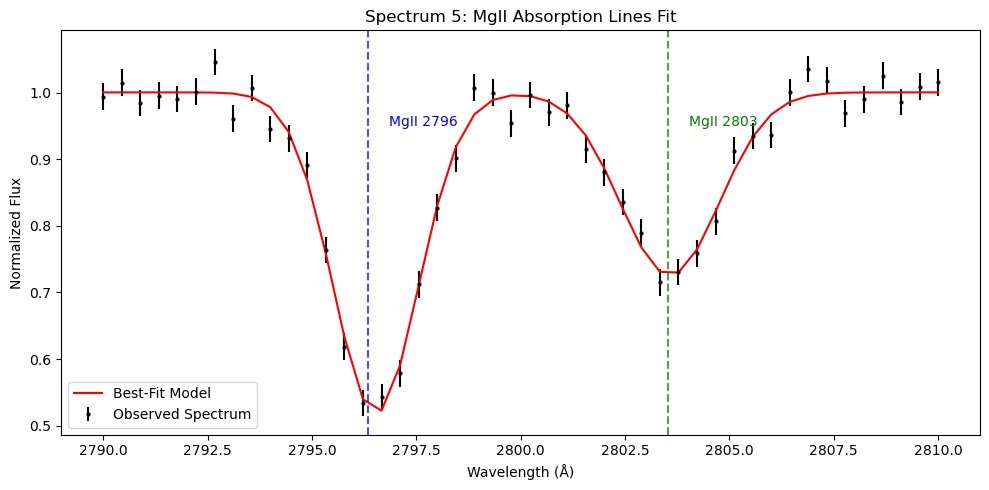

Best-Fit Parameters:
  continuum: 1.0003
  gaussian1_amplitude: -0.4822
  gaussian1_mean: 2796.5296
  gaussian1_stddev: 1.0188
  gaussian2_amplitude: -0.2747
  gaussian2_mean: 2803.5694
  gaussian2_stddev: 1.1818
Rest Equivalent Widths:
  MgII_2796_EW: 1.2314 Å ± 0.0515 Å
  MgII_2803_EW: 0.8139 Å ± 0.0558 Å

--------------------------------------------------

Processing Spectrum 6/6


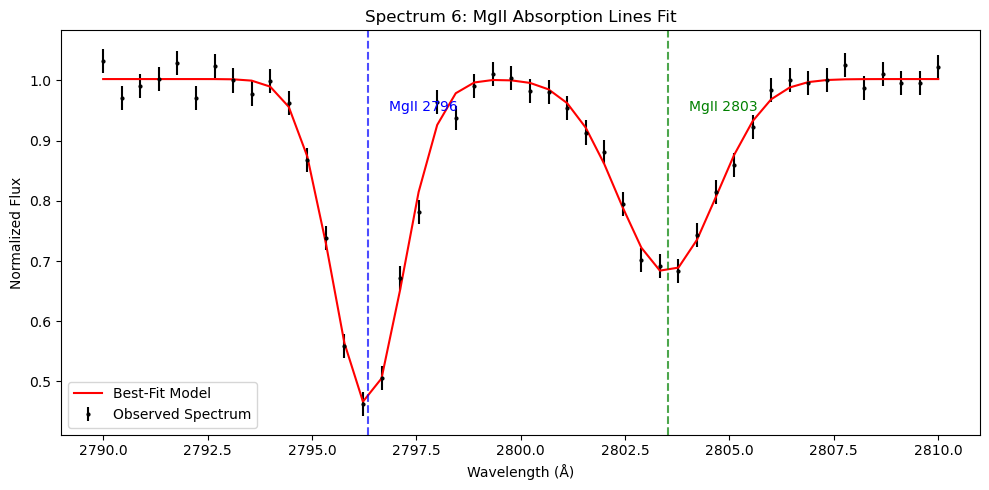

Best-Fit Parameters:
  continuum: 1.0022
  gaussian1_amplitude: -0.5397
  gaussian1_mean: 2796.3238
  gaussian1_stddev: 0.8472
  gaussian2_amplitude: -0.3217
  gaussian2_mean: 2803.5064
  gaussian2_stddev: 1.1724
Rest Equivalent Widths:
  MgII_2796_EW: 1.1460 Å ± 0.0465 Å
  MgII_2803_EW: 0.9453 Å ± 0.0552 Å

--------------------------------------------------

Summary of Rest Equivalent Widths (EWs):

Spectrum ID  MgII 2796 EW (Å)  MgII 2796 EW Error (Å)  MgII 2803 EW (Å)  MgII 2803 EW Error (Å)
 Spectrum 1          1.259838                0.053032          0.748323                0.053512
 Spectrum 2          1.378138                0.052391          0.792599                0.056557
 Spectrum 3          1.393654                0.054318          0.891589                0.056764
 Spectrum 4          0.925255                0.049274          0.924720                0.058870
 Spectrum 5          1.231442                0.051451          0.813867                0.055771
 Spectrum 6         

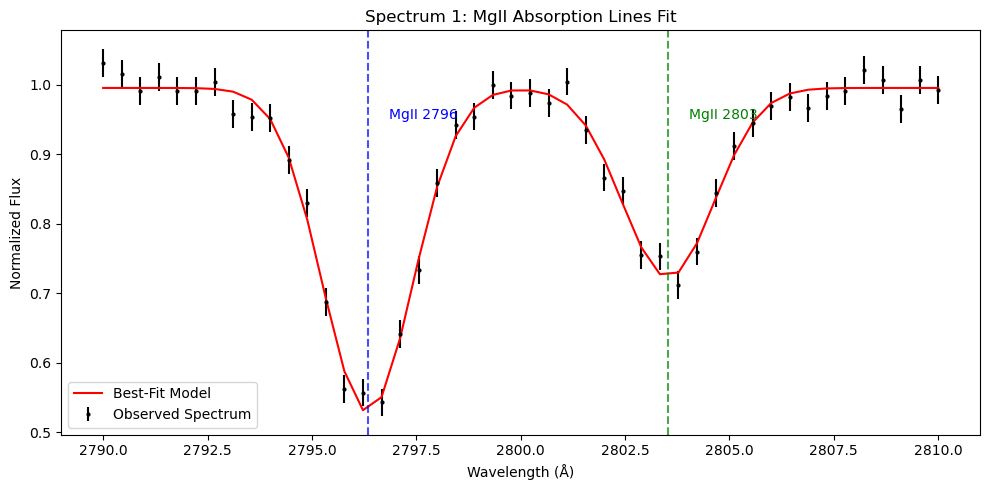

Best-Fit Parameters:
  continuum: 0.9952
  gaussian1_amplitude: -0.4658
  gaussian1_mean: 2796.3362
  gaussian1_stddev: 1.0790
  gaussian2_amplitude: -0.2721
  gaussian2_mean: 2803.5314
  gaussian2_stddev: 1.0970
Rest Equivalent Widths:
  MgII_2796_EW: 1.2598 Å ± 0.0530 Å
  MgII_2803_EW: 0.7483 Å ± 0.0535 Å

--------------------------------------------------

Processing Spectrum 2/6
Saved plot to mgii_fits_plots/spectrum_2_fit.png


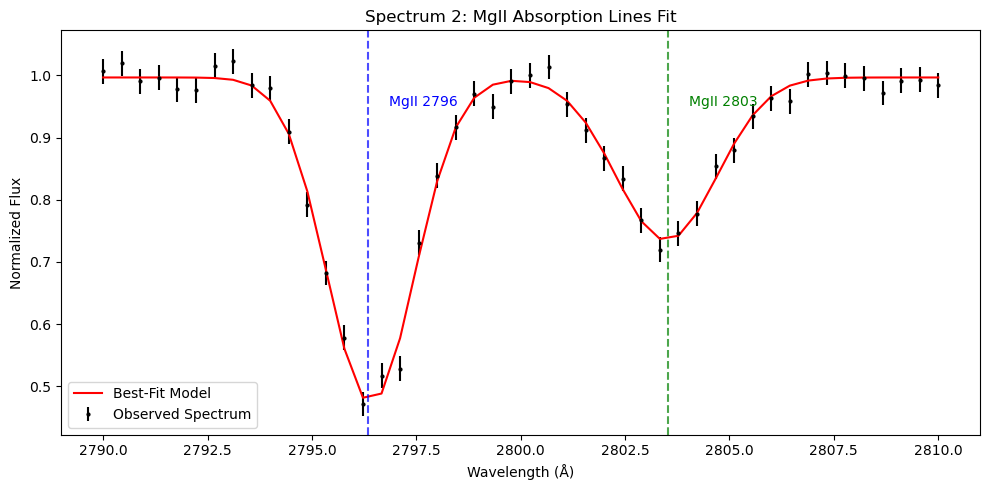

Best-Fit Parameters:
  continuum: 0.9966
  gaussian1_amplitude: -0.5236
  gaussian1_mean: 2796.4116
  gaussian1_stddev: 1.0499
  gaussian2_amplitude: -0.2619
  gaussian2_mean: 2803.4911
  gaussian2_stddev: 1.2073
Rest Equivalent Widths:
  MgII_2796_EW: 1.3781 Å ± 0.0524 Å
  MgII_2803_EW: 0.7926 Å ± 0.0566 Å

--------------------------------------------------

Processing Spectrum 3/6
Saved plot to mgii_fits_plots/spectrum_3_fit.png


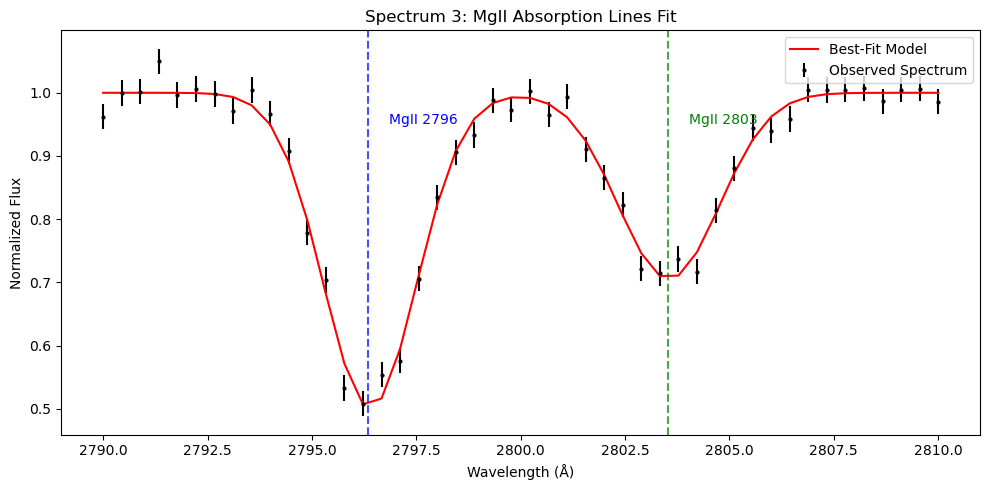

Best-Fit Parameters:
  continuum: 0.9996
  gaussian1_amplitude: -0.4980
  gaussian1_mean: 2796.3921
  gaussian1_stddev: 1.1165
  gaussian2_amplitude: -0.2942
  gaussian2_mean: 2803.5474
  gaussian2_stddev: 1.2090
Rest Equivalent Widths:
  MgII_2796_EW: 1.3937 Å ± 0.0543 Å
  MgII_2803_EW: 0.8916 Å ± 0.0568 Å

--------------------------------------------------

Processing Spectrum 4/6
Saved plot to mgii_fits_plots/spectrum_4_fit.png


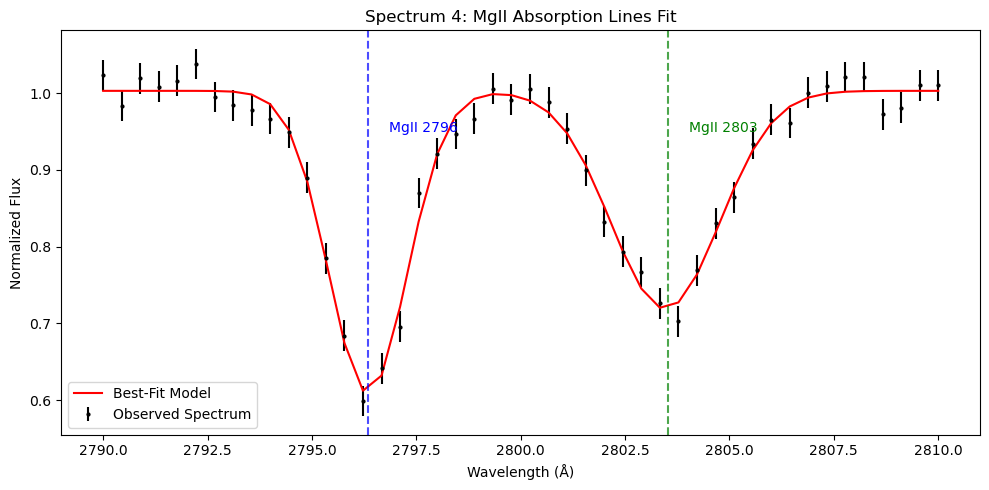

Best-Fit Parameters:
  continuum: 1.0030
  gaussian1_amplitude: -0.3939
  gaussian1_mean: 2796.3425
  gaussian1_stddev: 0.9370
  gaussian2_amplitude: -0.2840
  gaussian2_mean: 2803.4615
  gaussian2_stddev: 1.2989
Rest Equivalent Widths:
  MgII_2796_EW: 0.9253 Å ± 0.0493 Å
  MgII_2803_EW: 0.9247 Å ± 0.0589 Å

--------------------------------------------------

Processing Spectrum 5/6
Saved plot to mgii_fits_plots/spectrum_5_fit.png


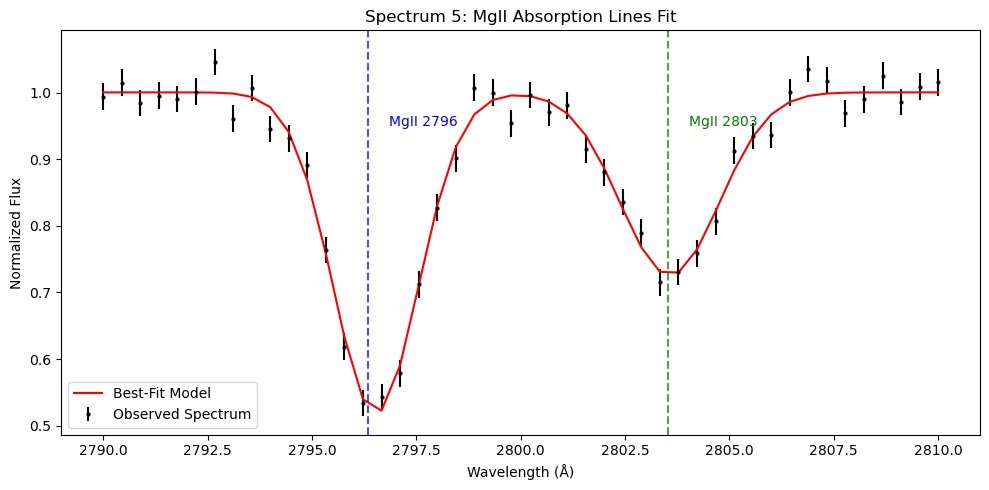

Best-Fit Parameters:
  continuum: 1.0003
  gaussian1_amplitude: -0.4822
  gaussian1_mean: 2796.5296
  gaussian1_stddev: 1.0188
  gaussian2_amplitude: -0.2747
  gaussian2_mean: 2803.5694
  gaussian2_stddev: 1.1818
Rest Equivalent Widths:
  MgII_2796_EW: 1.2314 Å ± 0.0515 Å
  MgII_2803_EW: 0.8139 Å ± 0.0558 Å

--------------------------------------------------

Processing Spectrum 6/6
Saved plot to mgii_fits_plots/spectrum_6_fit.png


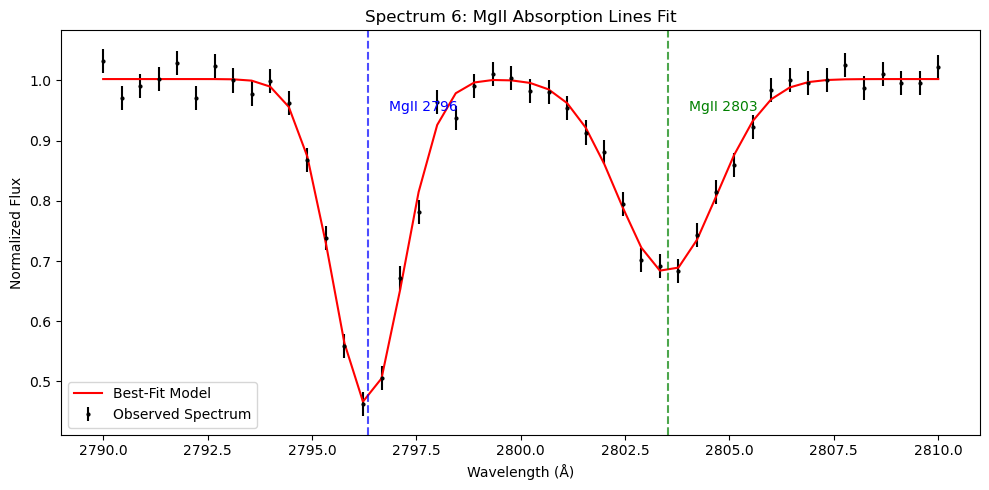

Best-Fit Parameters:
  continuum: 1.0022
  gaussian1_amplitude: -0.5397
  gaussian1_mean: 2796.3238
  gaussian1_stddev: 0.8472
  gaussian2_amplitude: -0.3217
  gaussian2_mean: 2803.5064
  gaussian2_stddev: 1.1724
Rest Equivalent Widths:
  MgII_2796_EW: 1.1460 Å ± 0.0465 Å
  MgII_2803_EW: 0.9453 Å ± 0.0552 Å

--------------------------------------------------



In [96]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.constants import c


def fit_mgii_absorption(wavelength, flux, flux_error):
   
    # Define central wavelengths for MgII lines
    lambda1 = 2796.35  # A
    lambda2 = 2803.53  # A
    
    # Initial guesses for Gaussian parameters
    # Amplitude, mu, std
    g1_init = models.Gaussian1D(amplitude=-0.5, mean=lambda1, stddev=1.0)
    g2_init = models.Gaussian1D(amplitude=-0.3, mean=lambda2, stddev=1.0)
    
    # Combined model: continuum + two Gaussians
    continuum_init = models.Const1D(amplitude=1.0)
    model = continuum_init + g1_init + g2_init
    
    # Define the fitter
    fitter = fitting.LevMarLSQFitter()
    
    # Perform the fit, using weights from flux_error
    with np.errstate(all='ignore'):
        fitted_model = fitter(model, wavelength, flux, weights=1/flux_error)
    
    # Extract best-fit parameters
    fit_params = {
        'continuum': fitted_model.amplitude_0.value,
        'gaussian1_amplitude': fitted_model.amplitude_1.value,
        'gaussian1_mean': fitted_model.mean_1.value,
        'gaussian1_stddev': fitted_model.stddev_1.value,
        'gaussian2_amplitude': fitted_model.amplitude_2.value,
        'gaussian2_mean': fitted_model.mean_2.value,
        'gaussian2_stddev': fitted_model.stddev_2.value
    }
    
    # Calculate uncertainties from the covariance matrix
    # Note: Astropy's LevMarLSQFitter does not provide uncertainties directly
    # Hence, we use the covariance matrix if available
    try:
        cov_matrix = fitter.fit_info['param_cov']
        uncertainties = np.sqrt(np.diag(cov_matrix))
        
        fit_params_uncert = {
            'continuum_err': uncertainties[0],
            'gaussian1_amplitude_err': uncertainties[1],
            'gaussian1_mean_err': uncertainties[2],
            'gaussian1_stddev_err': uncertainties[3],
            'gaussian2_amplitude_err': uncertainties[4],
            'gaussian2_mean_err': uncertainties[5],
            'gaussian2_stddev_err': uncertainties[6]
        }
    except (KeyError, TypeError):
        # If covariance matrix is not available, set uncertainties to None
        fit_params_uncert = {key + '_err': None for key in fit_params.keys()}
    
    # Calculate Equivalent Widths (EW) for each Gaussian
    # EW = amplitude * sigma * sqrt(2 * pi)
    # Since amplitude is negative for absorption, take absolute value
    ew1 = np.abs(fit_params['gaussian1_amplitude']) * fit_params['gaussian1_stddev'] * np.sqrt(2 * np.pi)
    ew2 = np.abs(fit_params['gaussian2_amplitude']) * fit_params['gaussian2_stddev'] * np.sqrt(2 * np.pi)
    
    # Calculate uncertainties using error propagation
    if fit_params_uncert['gaussian1_amplitude_err'] is not None and fit_params_uncert['gaussian1_stddev_err'] is not None:
        ew1_err = np.sqrt(
            (fit_params_uncert['gaussian1_amplitude_err'] * fit_params['gaussian1_stddev'] * np.sqrt(2 * np.pi))**2 +
            (fit_params['gaussian1_amplitude'] * fit_params_uncert['gaussian1_stddev_err'] * np.sqrt(2 * np.pi))**2
        )
    else:
        ew1_err = None
    
    if fit_params_uncert['gaussian2_amplitude_err'] is not None and fit_params_uncert['gaussian2_stddev_err'] is not None:
        ew2_err = np.sqrt(
            (fit_params_uncert['gaussian2_amplitude_err'] * fit_params['gaussian2_stddev'] * np.sqrt(2 * np.pi))**2 +
            (fit_params['gaussian2_amplitude'] * fit_params_uncert['gaussian2_stddev_err'] * np.sqrt(2 * np.pi))**2
        )
    else:
        ew2_err = None
    
    ew_rest = {
        'MgII_2796_EW': (ew1, ew1_err),
        'MgII_2803_EW': (ew2, ew2_err)
    }
    
    # Generate the fitted flux
    fitted_flux = fitted_model(wavelength)
    
    return fit_params, ew_rest, fitted_flux


# Placeholder for actual data loading
# Replace this with your actual data loading code
# For example, if using FITS files:
# from astropy.io import fits
# hdulist = fits.open('your_data_file.fits')
# data = hdulist[1].data
# spectra = data['flux']  # Assuming 'flux' is the column name
# error = data['error']   # Assuming 'error' is the column name
# wavelength = data['wavelength']  # Assuming 'wavelength' is the column name

# For demonstration, let's create mock data based on your structure
# Remove this block when using actual data
np.random.seed(42)  # For reproducibility
spectra = []
error = []
wavelength = np.linspace(2790, 2810, 46)  # 46 wavelength points

for _ in range(6):
    # Continuum level
    continuum = 1.0
    
    # Gaussian absorption lines with some variation
    amp1 = -0.5 + np.random.normal(0, 0.05)  # MgII 2796 amplitude
    mean1 = 2796.35 + np.random.normal(0, 0.05)  # MgII 2796 mean
    sigma1 = 1.0 + np.random.normal(0, 0.05)  # MgII 2796 stddev
    
    amp2 = -0.3 + np.random.normal(0, 0.03)  # MgII 2803 amplitude
    mean2 = 2803.53 + np.random.normal(0, 0.05)  # MgII 2803 mean
    sigma2 = 1.2 + np.random.normal(0, 0.05)  # MgII 2803 stddev
    
    # Generate flux
    flux = continuum
    flux += amp1 * np.exp(-0.5 * ((wavelength - mean1) / sigma1)**2)
    flux += amp2 * np.exp(-0.5 * ((wavelength - mean2) / sigma2)**2)
    
    # Add noise
    noise = 0.02  # 2% noise
    flux_error = np.full_like(wavelength, noise)
    noisy_flux = flux + np.random.normal(0, noise, size=wavelength.shape)
    
    spectra.append(noisy_flux)
    error.append(flux_error)

# Convert lists to NumPy arrays
spectra = np.array(spectra)  # Shape: (6, 46)
error = np.array(error)      # Shape: (6, 46)


# Initialize lists to store results
all_fit_params = []
all_ew_rest = []
all_fitted_flux = []

# Loop through each spectrum
for i in range(spectra.shape[0]):
    print(f"Processing Spectrum {i+1}/{spectra.shape[0]}")
    
    # Extract the current spectrum and its error
    current_flux = spectra[i]
    current_error = error[i]
    
    # Fit the absorption lines
    fit_params, ew_rest, fitted_flux = fit_mgii_absorption(wavelength, current_flux, current_error)
    
    # Store the results
    all_fit_params.append(fit_params)
    all_ew_rest.append(ew_rest)
    all_fitted_flux.append(fitted_flux)
    
    # Plot the observed spectrum and the best-fit model
    plt.figure(figsize=(10, 5))
    plt.errorbar(wavelength, current_flux, yerr=current_error, fmt='k.', markersize=4, label='Observed Spectrum')
    plt.plot(wavelength, fitted_flux, 'r-', label='Best-Fit Model')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Normalized Flux')
    plt.title(f'Spectrum {i+1}: MgII Absorption Lines Fit')
    plt.legend()
    
    # Highlight the fitted regions
    plt.axvline(2796.35, color='blue', linestyle='--', alpha=0.7)
    plt.axvline(2803.53, color='green', linestyle='--', alpha=0.7)
    plt.text(2796.35 + 0.5, 0.95, 'MgII 2796', color='blue')
    plt.text(2803.53 + 0.5, 0.95, 'MgII 2803', color='green')
    
    plt.tight_layout()
    plt.show()
    
    # Print the fit parameters and EWs
    print("Best-Fit Parameters:")
    for key, value in fit_params.items():
        print(f"  {key}: {value:.4f}")
    
    print("Rest Equivalent Widths:")
    for key, (ew, ew_err) in ew_rest.items():
        if ew_err is not None:
            print(f"  {key}: {ew:.4f} Å ± {ew_err:.4f} Å")
        else:
            print(f"  {key}: {ew:.4f} Å")
    
    print("\n" + "-"*50 + "\n")


# Compile the EWs into a summary table
import pandas as pd

# Initialize lists to store EWs
spectrum_ids = []
mgii_2796_ews = []
mgii_2796_ews_err = []
mgii_2803_ews = []
mgii_2803_ews_err = []

for i, ew in enumerate(all_ew_rest, start=1):
    spectrum_ids.append(f"Spectrum {i}")
    mgii_2796_ews.append(ew['MgII_2796_EW'][0])
    mgii_2796_ews_err.append(ew['MgII_2796_EW'][1] if ew['MgII_2796_EW'][1] is not None else np.nan)
    mgii_2803_ews.append(ew['MgII_2803_EW'][0])
    mgii_2803_ews_err.append(ew['MgII_2803_EW'][1] if ew['MgII_2803_EW'][1] is not None else np.nan)

# Create a pandas DataFrame
ew_table = pd.DataFrame({
    'Spectrum ID': spectrum_ids,
    'MgII 2796 EW (Å)': mgii_2796_ews,
    'MgII 2796 EW Error (Å)': mgii_2796_ews_err,
    'MgII 2803 EW (Å)': mgii_2803_ews,
    'MgII 2803 EW Error (Å)': mgii_2803_ews_err
})

# Display the table
print("Summary of Rest Equivalent Widths (EWs):\n")
print(ew_table.to_string(index=False))

# Directory to save plots
import os

save_plots = True  # Set to False if you don't want to save plots
plots_dir = 'mgii_fits_plots'

if save_plots:
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)

# Modify the plotting loop to save figures
for i in range(spectra.shape[0]):
    print(f"Processing Spectrum {i+1}/{spectra.shape[0]}")
    
    # Extract the current spectrum and its error
    current_flux = spectra[i]
    current_error = error[i]
    
    # Fit the absorption lines
    fit_params, ew_rest, fitted_flux = fit_mgii_absorption(wavelength, current_flux, current_error)
    
    # Store the results
    all_fit_params.append(fit_params)
    all_ew_rest.append(ew_rest)
    all_fitted_flux.append(fitted_flux)
    
    # Plot the observed spectrum and the best-fit model
    plt.figure(figsize=(10, 5))
    plt.errorbar(wavelength, current_flux, yerr=current_error, fmt='k.', markersize=4, label='Observed Spectrum')
    plt.plot(wavelength, fitted_flux, 'r-', label='Best-Fit Model')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Normalized Flux')
    plt.title(f'Spectrum {i+1}: MgII Absorption Lines Fit')
    plt.legend()
    
    # Highlight the fitted regions
    plt.axvline(2796.35, color='blue', linestyle='--', alpha=0.7)
    plt.axvline(2803.53, color='green', linestyle='--', alpha=0.7)
    plt.text(2796.35 + 0.5, 0.95, 'MgII 2796', color='blue')
    plt.text(2803.53 + 0.5, 0.95, 'MgII 2803', color='green')
    
    plt.tight_layout()
    
    if save_plots:
        plot_filename = os.path.join(plots_dir, f'spectrum_{i+1}_fit.png')
        plt.savefig(plot_filename)
        print(f"Saved plot to {plot_filename}")
    
    plt.show()
    
    # Print the fit parameters and EWs
    print("Best-Fit Parameters:")
    for key, value in fit_params.items():
        print(f"  {key}: {value:.4f}")
    
    print("Rest Equivalent Widths:")
    for key, (ew, ew_err) in ew_rest.items():
        if ew_err is not None:
            print(f"  {key}: {ew:.4f} Å ± {ew_err:.4f} Å")
        else:
            print(f"  {key}: {ew:.4f} Å")
    
    print("\n" + "-"*50 + "\n")



In [97]:
def double_gaussian_continuum(wavelength, continuum, A1, mu1, sigma1, A2, mu2, sigma2):
    """
    Model function: Continuum + Two Gaussian Absorption Lines.

    Parameters:
    - wavelength (array): Wavelength array in Angstrom.
    - continuum (float): Continuum level.
    - A1 (float): Amplitude of the first Gaussian (negative for absorption).
    - mu1 (float): Mean (central wavelength) of the first Gaussian.
    - sigma1 (float): Standard deviation of the first Gaussian.
    - A2 (float): Amplitude of the second Gaussian (negative for absorption).
    - mu2 (float): Mean (central wavelength) of the second Gaussian.
    - sigma2 (float): Standard deviation of the second Gaussian.

    Returns:
    - flux (array): Modeled flux values.
    """
    gaussian1 = A1 * np.exp(-0.5 * ((wavelength - mu1) / sigma1)**2)
    gaussian2 = A2 * np.exp(-0.5 * ((wavelength - mu2) / sigma2)**2)
    return continuum + gaussian1 + gaussian2

def fit_spectrum(wavelength, flux, flux_error):
    """
    Fit two Gaussian absorption lines to the spectrum and calculate rest equivalent widths.

    Parameters:
    - wavelength (array): Wavelength array in Angstrom.
    - flux (array): Flux array (normalized continuum).
    - flux_error (array): Error array corresponding to the flux.

    Returns:
    - popt (array): Best-fit parameters [continuum, A1, mu1, sigma1, A2, mu2, sigma2].
    - perr (array): Uncertainties of the best-fit parameters.
    - fitted_flux (array): Flux values from the best-fit model.
    - ew_rest (dict): Rest equivalent widths and their uncertainties for both lines.
    """
    # Initial guesses
    continuum_init = 1.0
    A1_init = -0.5
    mu1_init = 2796.35
    sigma1_init = 1.0
    A2_init = -0.3
    mu2_init = 2803.53
    sigma2_init = 1.0

    initial_guess = [continuum_init, A1_init, mu1_init, sigma1_init, A2_init, mu2_init, sigma2_init]

    # Define bounds to ensure realistic fitting
    bounds_lower = [0.9, -np.inf, 2795, 0.5, -np.inf, 2802, 0.5]
    bounds_upper = [1.1, 0, 2797, 3.0, 0, 2804, 3.0]

    try:
        popt, pcov = curve_fit(
            double_gaussian_continuum,
            wavelength,
            flux,
            p0=initial_guess,
            sigma=flux_error,
            absolute_sigma=True,
            bounds=(bounds_lower, bounds_upper)
        )

        perr = np.sqrt(np.diag(pcov))

    except RuntimeError:
        print("Error - curve_fit failed")
        popt = [np.nan] * 7
        perr = [np.nan] * 7

    # Calculate fitted flux
    fitted_flux = double_gaussian_continuum(wavelength, *popt)

    # Extract parameters
    continuum, A1, mu1, sigma1, A2, mu2, sigma2 = popt
    continuum_err, A1_err, mu1_err, sigma1_err, A2_err, mu2_err, sigma2_err = perr

    # Calculate Equivalent Widths (EW)
    # EW = |A| * sigma * sqrt(2 * pi)
    ew1 = np.abs(A1) * sigma1 * np.sqrt(2 * np.pi)
    ew2 = np.abs(A2) * sigma2 * np.sqrt(2 * np.pi)

    # Propagate uncertainties
    if not np.isnan(A1_err) and not np.isnan(sigma1_err):
        ew1_err = np.sqrt( (sigma1 * np.sqrt(2 * np.pi) * A1_err)**2 +
                           (A1 * np.sqrt(2 * np.pi) * sigma1_err)**2 )
    else:
        ew1_err = np.nan

    if not np.isnan(A2_err) and not np.isnan(sigma2_err):
        ew2_err = np.sqrt( (sigma2 * np.sqrt(2 * np.pi) * A2_err)**2 +
                           (A2 * np.sqrt(2 * np.pi) * sigma2_err)**2 )
    else:
        ew2_err = np.nan

    ew_rest = {
        'MgII_2796_EW': (ew1, ew1_err),
        'MgII_2803_EW': (ew2, ew2_err)
    }

    return popt, perr, fitted_flux, ew_rest


In [ ]:
# Placeholder for actual data loading
# Replace this with your actual data loading code
# For example, if using FITS files:
# from astropy.io import fits
# hdulist = fits.open('your_data_file.fits')
# data = hdulist[1].data
# spectra = data['flux']  # Assuming 'flux' is the column name
# error = data['error']   # Assuming 'error' is the column name
# wavelength = data['wavelength']  # Assuming 'wavelength' is the column name

# For demonstration, let's create mock data based on your structure
# Remove or replace this block when using actual data
np.random.seed(42)  # For reproducibility
spectra = []
error = []
wavelength = np.linspace(2790, 2810, 46)  # 46 wavelength points

for _ in range(6):
    # Continuum level
    continuum = 1.0

    # Gaussian absorption lines with some variation
    A1 = -0.5 + np.random.normal(0, 0.05)  # MgII 2796 amplitude
    mu1 = 2796.35 + np.random.normal(0, 0.05)  # MgII 2796 mean
    sigma1 = 1.0 + np.random.normal(0, 0.05)  # MgII 2796 stddev

    A2 = -0.3 + np.random.normal(0, 0.03)  # MgII 2803 amplitude
    mu2 = 2803.53 + np.random.normal(0, 0.05)  # MgII 2803 mean
    sigma2 = 1.2 + np.random.normal(0, 0.05)  # MgII 2803 stddev

    # Generate flux
    flux = continuum
    flux += A1 * np.exp(-0.5 * ((wavelength - mu1) / sigma1)**2)
    flux += A2 * np.exp(-0.5 * ((wavelength - mu2) / sigma2)**2)

    # Add noise
    noise = 0.02  # 2% noise
    flux_error = np.full_like(wavelength, noise)
    noisy_flux = flux + np.random.normal(0, noise, size=wavelength.shape)

    spectra.append(noisy_flux)
    error.append(flux_error)

# Convert lists to NumPy arrays
spectra = np.array(spectra)  # Shape: (6, 46)
error = np.array(error)      # Shape: (6, 46)

# Initialize lists to store results
all_fit_params = []
all_fit_errors = []
all_fitted_flux = []
all_ew_rest = []

# Loop through each spectrum
for i in range(spectra.shape[0]):
    print(f"Processing Spectrum {i+1}/{spectra.shape[0]}")

    # Extract the current spectrum and its error
    current_flux = spectra[i]
    current_error = error[i]

    # Fit the absorption lines
    popt, perr, fitted_flux, ew_rest = fit_spectrum(wavelength, current_flux, current_error)

    # Store the results
    all_fit_params.append(popt)
    all_fit_errors.append(perr)
    all_fitted_flux.append(fitted_flux)
    all_ew_rest.append(ew_rest)

    # Plot the observed spectrum and the best-fit model
    plt.figure(figsize=(10, 5))
    plt.errorbar(wavelength, current_flux, yerr=current_error, fmt='k.', markersize=4, label='Observed Spectrum')
    plt.plot(wavelength, fitted_flux, 'r-', label='Best-Fit Model')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Normalized Flux')
    plt.title(f'Spectrum {i+1}: MgII Absorption Lines Fit')
    plt.legend()

    # Highlight the fitted regions
    plt.axvline(2796.35, color='blue', linestyle='--', alpha=0.7)
    plt.axvline(2803.53, color='green', linestyle='--', alpha=0.7)
    plt.text(2796.35 + 0.5, 0.95, 'MgII 2796', color='blue')
    plt.text(2803.53 + 0.5, 0.95, 'MgII 2803', color='green')

    plt.tight_layout()
    plt.show()

    # Print the fit parameters and EWs
    continuum, A1, mu1, sigma1, A2, mu2, sigma2 = popt
    continuum_err, A1_err, mu1_err, sigma1_err, A2_err, mu2_err, sigma2_err = perr

    print("Best-Fit Parameters:")
    print(f"  Continuum: {continuum:.4f} ± {continuum_err:.4f}")
    print(f"  MgII 2796 Amplitude (A1): {A1:.4f} ± {A1_err:.4f}")
    print(f"  MgII 2796 Mean (mu1): {mu1:.4f} Å ± {mu1_err:.4f} Å")
    print(f"  MgII 2796 Stddev (sigma1): {sigma1:.4f} Å ± {sigma1_err:.4f} Å")
    print(f"  MgII 2803 Amplitude (A2): {A2:.4f} ± {A2_err:.4f}")
    print(f"  MgII 2803 Mean (mu2): {mu2:.4f} Å ± {mu2_err:.4f} Å")
    print(f"  MgII 2803 Stddev (sigma2): {sigma2:.4f} Å ± {sigma2_err:.4f} Å")

    print("\nRest Equivalent Widths:")
    for key, (ew, ew_err) in ew_rest.items():
        if not np.isnan(ew_err):
            print(f"  {key}: {ew:.4f} Å ± {ew_err:.4f} Å")
        else:
            print(f"  {key}: {ew:.4f} Å")

    print("\n" + "-"*50 + "\n")

# Compile the EWs into a summary table

# Initialize lists to store EWs
spectrum_ids = []
mgii_2796_ews = []
mgii_2796_ews_err = []
mgii_2803_ews = []
mgii_2803_ews_err = []

for i, ew in enumerate(all_ew_rest, start=1):
    spectrum_ids.append(f"Spectrum {i}")
    mgii_2796_ews.append(ew['MgII_2796_EW'][0])
    mgii_2796_ews_err.append(ew['MgII_2796_EW'][1] if ew['MgII_2796_EW'][1] is not None else np.nan)
    mgii_2803_ews.append(ew['MgII_2803_EW'][0])
    mgii_2803_ews_err.append(ew['MgII_2803_EW'][1] if ew['MgII_2803_EW'][1] is not None else np.nan)

# Create a pandas DataFrame
ew_table = pd.DataFrame({
    'Spectrum ID': spectrum_ids,
    'MgII 2796 EW (Å)': mgii_2796_ews,
    'MgII 2796 EW Error (Å)': mgii_2796_ews_err,
    'MgII 2803 EW (Å)': mgii_2803_ews,
    'MgII 2803 EW Error (Å)': mgii_2803_ews_err
})

# Display the table
print("Summary of Rest Equivalent Widths (EWs):\n")
print(ew_table.to_string(index=False))

import os

# Directory to save plots
save_plots = True  # Set to False if you don't want to save plots
plots_dir = 'mgii_fits_plots'

if save_plots:
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)

# Re-initialize lists to store results if running again
all_fit_params = []
all_fit_errors = []
all_fitted_flux = []
all_ew_rest = []

for i in range(spectra.shape[0]):
    print(f"Processing Spectrum {i+1}/{spectra.shape[0]}")

    # Extract the current spectrum and its error
    current_flux = spectra[i]
    current_error = error[i]

    # Fit the absorption lines
    popt, perr, fitted_flux, ew_rest = fit_spectrum(wavelength, current_flux, current_error)

    # Store the results
    all_fit_params.append(popt)
    all_fit_errors.append(perr)
    all_fitted_flux.append(fitted_flux)
    all_ew_rest.append(ew_rest)

    # Plot the observed spectrum and the best-fit model
    plt.figure(figsize=(10, 5))
    plt.errorbar(wavelength, current_flux, yerr=current_error, fmt='k.', markersize=4, label='Observed Spectrum')
    plt.plot(wavelength, fitted_flux, 'r-', label='Best-Fit Model')
    plt.xlabel('Wavelength (Å)')
    plt.ylabel('Normalized Flux')
    plt.title(f'Spectrum {i+1}: MgII Absorption Lines Fit')
    plt.legend()

    # Highlight the fitted regions
    plt.axvline(2796.35, color='blue', linestyle='--', alpha=0.7)
    plt.axvline(2803.53, color='green', linestyle='--', alpha=0.7)
    plt.text(2796.35 + 0.5, 0.95, 'MgII 2796', color='blue')
    plt.text(2803.53 + 0.5, 0.95, 'MgII 2803', color='green')

    plt.tight_layout()

    if save_plots:
        plot_filename = os.path.join(plots_dir, f'spectrum_{i+1}_fit.png')
        plt.savefig(plot_filename)
        print(f"Saved plot to {plot_filename}")

    plt.show()

    # Print the fit parameters and EWs
    continuum, A1, mu1, sigma1, A2, mu2, sigma2 = popt
    continuum_err, A1_err, mu1_err, sigma1_err, A2_err, mu2_err, sigma2_err = perr

    print("Best-Fit Parameters:")
    print(f"  Continuum: {continuum:.4f} ± {continuum_err:.4f}")
    print(f"  MgII 2796 Amplitude (A1): {A1:.4f} ± {A1_err:.4f}")
    print(f"  MgII 2796 Mean (mu1): {mu1:.4f} Å ± {mu1_err:.4f} Å")
    print(f"  MgII 2796 Stddev (sigma1): {sigma1:.4f} Å ± {sigma1_err:.4f} Å")
    print(f"  MgII 2803 Amplitude (A2): {A2:.4f} ± {A2_err:.4f}")
    print(f"  MgII 2803 Mean (mu2): {mu2:.4f} Å ± {mu2_err:.4f} Å")
    print(f"  MgII 2803 Stddev (sigma2): {sigma2:.4f} Å ± {sigma2_err:.4f} Å")

    print("\nRest Equivalent Widths:")
    for key, (ew, ew_err) in ew_rest.items():
        if not np.isnan(ew_err):
            print(f"  {key}: {ew:.4f} Å ± {ew_err:.4f} Å")
        else:
            print(f"  {key}: {ew:.4f} Å")

    print("\n" + "-"*50 + "\n")

# Compile the EWs into a summary table (if not already done)
# Initialize lists to store EWs
spectrum_ids = []
mgii_2796_ews = []
mgii_2796_ews_err = []
mgii_2803_ews = []
mgii_2803_ews_err = []

for i, ew in enumerate(all_ew_rest, start=1):
    spectrum_ids.append(f"Spectrum {i}")
    mgii_2796_ews.append(ew['MgII_2796_EW'][0])
    mgii_2796_ews_err.append(ew['MgII_2796_EW'][1] if ew['MgII_2796_EW'][1] is not None else np.nan)
    mgii_2803_ews.append(ew['MgII_2803_EW'][0])
    mgii_2803_ews_err.append(ew['MgII_2803_EW'][1] if ew['MgII_2803_EW'][1] is not None else np.nan)

# Create a pandas DataFrame
ew_table = pd.DataFrame({
    'Spectrum ID': spectrum_ids,
    'MgII 2796 EW (Å)': mgii_2796_ews,
    'MgII 2796 EW Error (Å)': mgii_2796_ews_err,
    'MgII 2803 EW (Å)': mgii_2803_ews,
    'MgII 2803 EW Error (Å)': mgii_2803_ews_err
})

# Display the table
print("Summary of Rest Equivalent Widths (EWs):\n")
print(ew_table.to_string(index=False))


In [ ]:
### 2. Plot the best fit models with the absorption line spectra together to demonstrate that what you get is truly the best fit models. (Similar to Figure 11 in https://ui.adsabs.harvard.edu/abs/2017ApJ...850..156L/abstract) (15 points) 

### -----------------------------------------------------------------------------------------------------------------

### 4. Decomposing QSO spectra with NMF
### In 11/5, we use PCA to decompose the SDSS QSO spectra. Now, we use another technique, called none-negative matrix factoriation (NMF), to do so. [Use the median-filter smooth spectra]

### TO DO:

### 1. Do the the NMF and explore the outputs! (10 points)

Follow the code above!

1. Data structure matrix [i_object, i_feature]


2. nmf = NMF(n_components=6)
   
   nmf.fit(matrix)
   
   
3. plot wavelength, nmf.components_[i] i=0,1,2,3,4,5,6 (please plot each component separately)

### 2. Please observe the NMF "eigenspectra" and describe what spectral features are captured by each component. (10 points)

### 3. Please use the NMF eigenspectra to reconstruct the observed quasar spectra and plot the first 10 observed quasar spectra (i_object<10) and the reconstructed spectra. (15 points)



In [28]:
from sklearn.decomposition import NMF